In [33]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


<center style="font-family:verdana;"><h1 style="font-size:200%; padding: 10px; background: darkgreen;"><b style="color:yellow;">Let All the Kagglers Boggie!</b></h1></center>

"There's a Starwoman waiting in the sky

She'd like to come and meet us

But she thinks she'd blow their minds

There's a StarWoman waiting in the sky

She's told us not to blow it

'Cause she knows it's all worthwhile

She told me / Let the kagglers lose it/ Let the kagglers use it/ Let all the kagglers boogie!



Source: Musixmatch

Author: David Bowie

Lyrics of Starman © Chrysalis Music Ltd., Tintoretto Music, Chrysalis Music Ltd, Rzo Music Ltd

<iframe width="713" height="401" src="https://www.youtube.com/embed/7SsDyc5FU94" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

#David Bowie - Starman (Live on TFI Friday 1999 / 2000) - HQ / HD /High Quality

https://www.youtube.com/watch?v=7SsDyc5FU94

In [34]:
train = pd.read_csv('../input/spaceship-titanic/train.csv')
pd.set_option('display.max_columns', None)
test = pd.read_csv('../input/spaceship-titanic/test.csv')
sub = pd.read_csv('../input/spaceship-titanic/sample_submission.csv')

In [35]:
train.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


In [36]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [37]:
train["HomePlanet"].value_counts()

Earth     4602
Europa    2131
Mars      1759
Name: HomePlanet, dtype: int64

#Earth, Europe and Mars???? Really?  Europa is a Home Planet? 

In [39]:
train["Destination"].value_counts()

TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: Destination, dtype: int64

In [40]:
!pip install pycomp

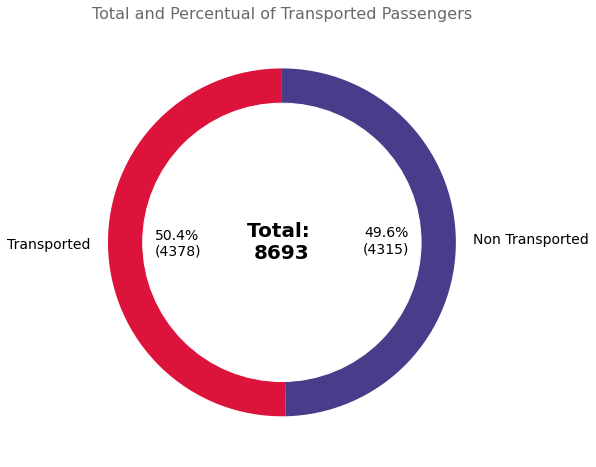

In [54]:
# Importing libraries
from pycomp.viz.insights import *

# Transported rate
transported_map = {False: 'Non Transported', True: 'Transported'}
transported_colors = ['crimson', 'darkslateblue']
plot_donut_chart(df=train, col='Transported', label_names=transported_map, colors=transported_colors,
                 title='Total and Percentual of Transported Passengers')

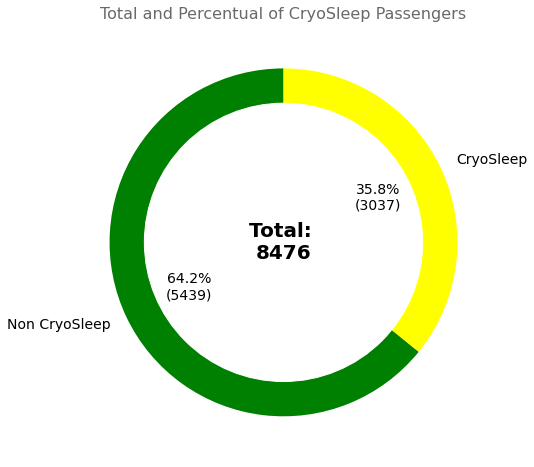

In [42]:
# CryoSleep rate
cryo_map = {False: 'Non CryoSleep', True: 'CryoSleep'}
cryo_colors = ['green', 'yellow']
plot_donut_chart(df=train, col='CryoSleep', label_names=cryo_map, colors=cryo_colors,
                 title='Total and Percentual of CryoSleep Passengers')

#The 1st time I heard about Cryo was refered to Walt Disney

![](https://cdn.quotesgram.com/img/55/89/82413333-funny-Walt-Disney-frozen-Simba1.jpg)quotesgram.com

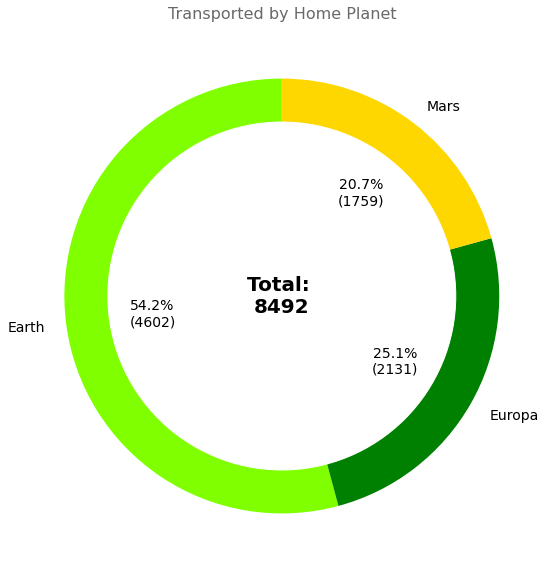

In [43]:
# Home Planet rate

HomePlanet_colors = ['chartreuse', 'green', 'Gold']
plot_donut_chart(df=train, col='HomePlanet', colors=HomePlanet_colors, figsize=(10, 10),
                 title='Transported by Home Planet')

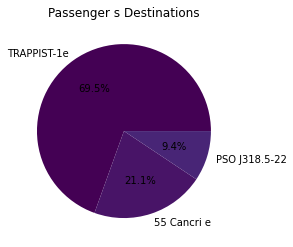

In [44]:
#Code by Taha07  https://www.kaggle.com/taha07/data-scientists-jobs-analysis-visualization/notebook

color = plt.cm.viridis(np.linspace(0,1,20))
train["Destination"].value_counts().sort_values(ascending=False).head(10).plot.pie(y="Destination",colors=color,autopct="%0.1f%%")
plt.title("Passenger s Destinations")
plt.axis("off")
plt.show()

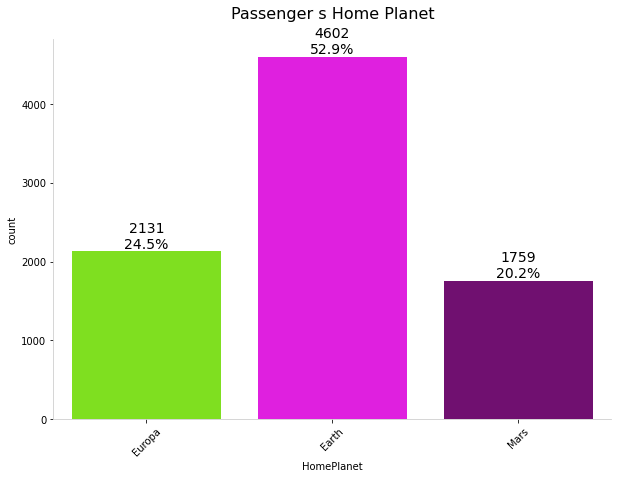

In [45]:
# Countplot for Home Planet
HomePlanet_colors = ['chartreuse', 'magenta',  'purple']

plot_countplot(df=train, col='HomePlanet', palette=HomePlanet_colors, 
               title='Passenger s Home Planet')
plt.xticks(rotation=45);

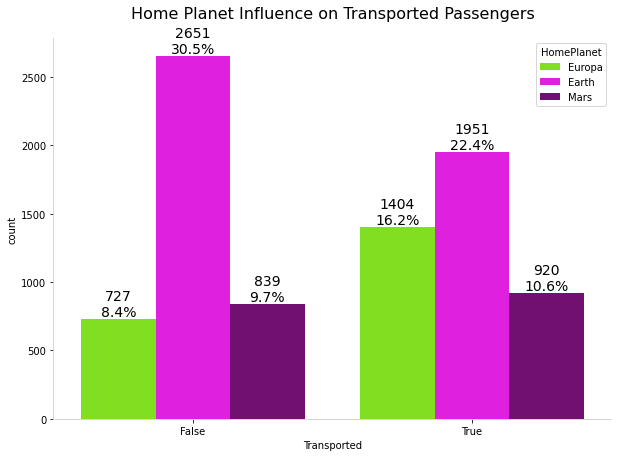

In [46]:
 # Transported rate by Home Planet
plot_countplot(df=train, col='Transported', hue='HomePlanet',  palette=HomePlanet_colors,
               title="Home Planet Influence on Transported Passengers")

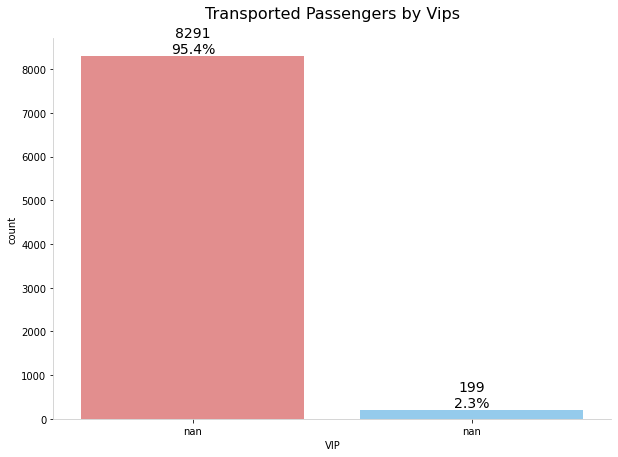

In [47]:
# Countplot for gender
vip_colors = ['lightcoral', 'lightskyblue']
vip_map = {'t': 'T', 'f': 'F'}
plot_countplot(df=train, col='VIP', palette=vip_colors, label_names=vip_map,
               title='Transported Passengers by Vips')

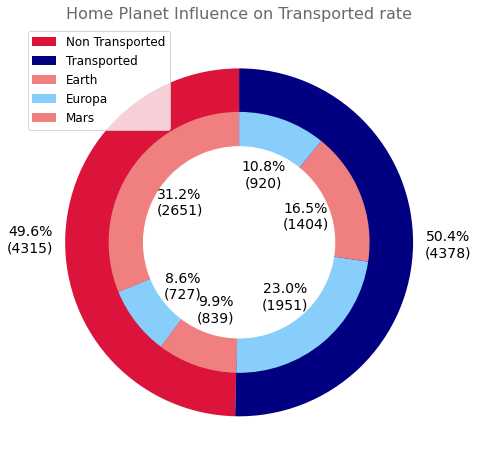

In [56]:
# Plotting a double donut chart
plot_double_donut_chart(df=train, col1='Transported', col2='HomePlanet', label_names_col1=transported_map, 
                        colors1=['crimson', 'navy'], colors2=['lightcoral', 'lightskyblue'],
                        title="Home Planet Influence on Transported rate")

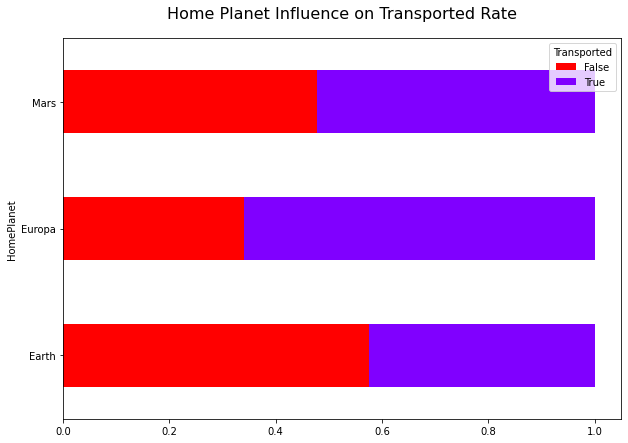

In [57]:
plot_pct_countplot(df=train, col='HomePlanet', hue='Transported', palette='rainbow_r',
                   title='Home Planet Influence on Transported Rate')

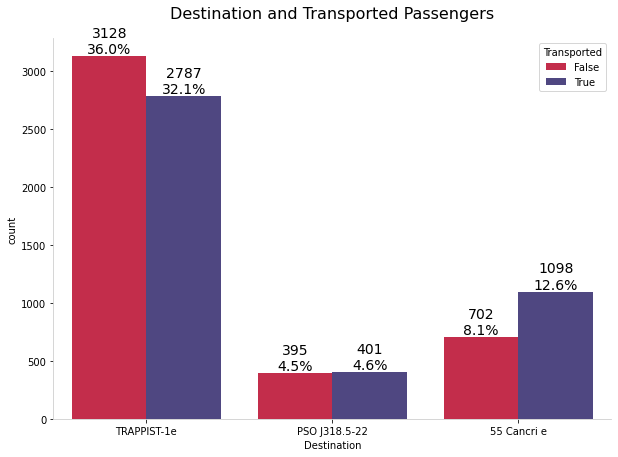

In [58]:
# Relationship between Autism in Family Members and Autism
plot_countplot(df=train, col='Destination', hue='Transported', orient='v', palette=transported_colors,
               title='Destination and Transported Passengers')

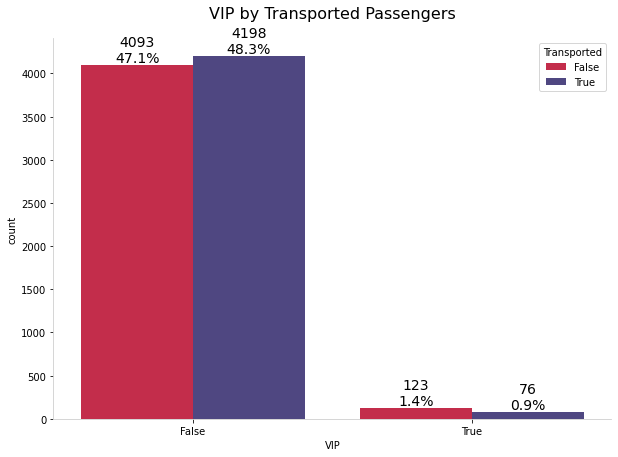

In [59]:
# Relationship between used_app_before and Autism
plot_countplot(df=train, col='VIP', hue='Transported', orient='v', palette=transported_colors,
               title='VIP by Transported Passengers')

The Majority is Not VIP??? Very Democratical Spaceship

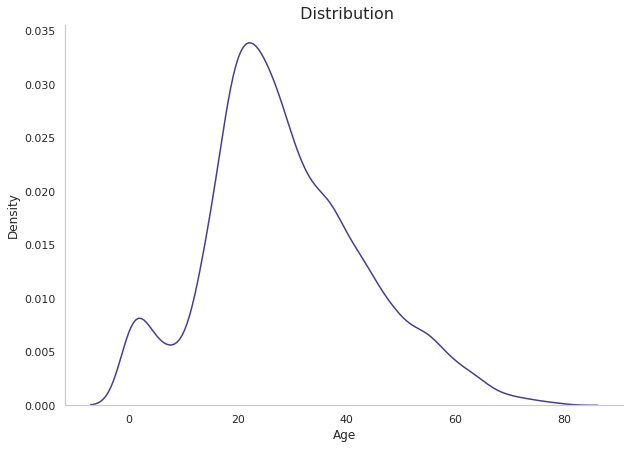

In [60]:
# Distribution of age variable
plot_distplot(df=train, col='Age', title=" Distribution")

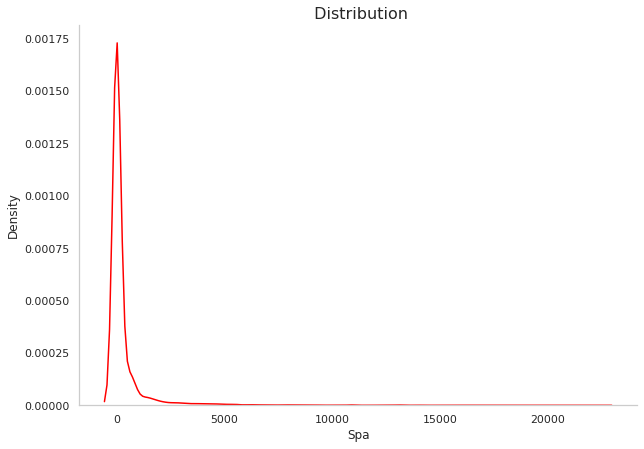

In [62]:
# Distribution of age variable
plot_distplot(df=train, col='Spa', title=" Distribution", color='red')

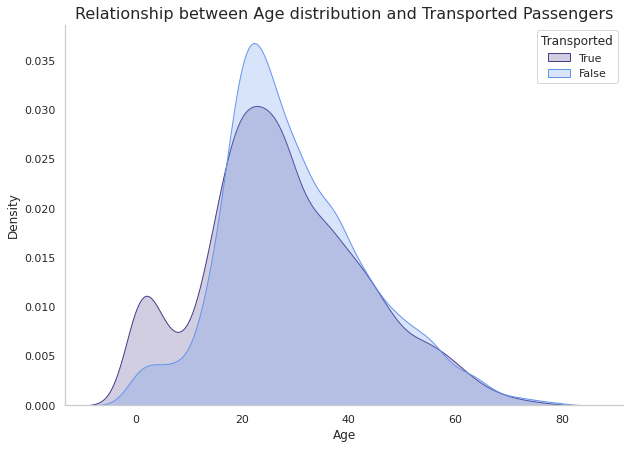

In [63]:
plot_distplot(df=train, col='Age', hue='Transported', kind='kde',
              title="Relationship between Age distribution and Transported Passengers")

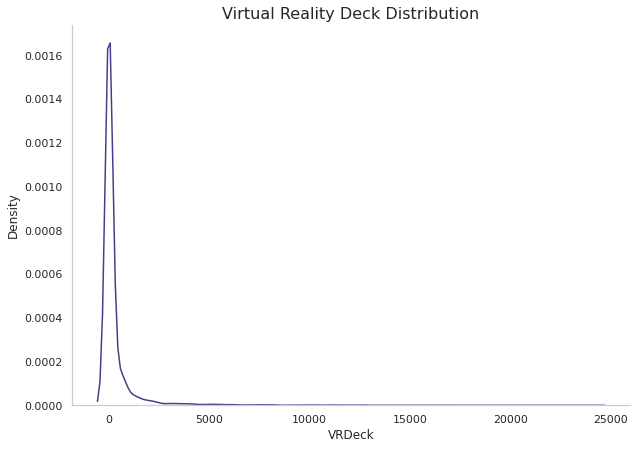

In [65]:
plot_distplot(df=train, col='VRDeck', title='Virtual Reality Deck Distribution')

#Acknowledgement

PyComp Library by Thiago Panini @thiagopanini

Codes by Thiago Panini https://www.kaggle.com/thiagopanini/pycomp-predicting-survival-on-titanic-disaster/notebook

https://pypi.org/project/pycomp/

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRAzM1i7JRvY1Zd59NYmvClwuY9SynIsyEUfg&usqp=CAU)memegenerator.net

#After hearing The Magnificent Bowie/Starman, these codes have no longer Any importance. At all! 